# Attack Profile Frame Review

Purpose: Audit attack-profile geometry and render representative frames for profile-level visual QA.

Role in project: diagnostic QA notebook

Inputs:
- default attack-profile library
- convoy profile

Outputs:
- audit CSV/JSON and preview frames under `results/notebook-results/attack_profile_tests/`

Expected runtime: medium for full profile rendering.

Notes:
- Use profile filters in the configuration cell for targeted review.


## Imports And Repo Setup


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
import csv
import json
import subprocess
import importlib
import numpy as np
import matplotlib.pyplot as plt

import convoy_sim.viz_attack as viz_attack
importlib.reload(viz_attack)

from convoy_sim.attack_profiles import AttackProfileLibrary, DEFAULT_ATTACK_PROFILE_LIBRARY
from convoy_sim.dynamics import ConvoyFormation, ConvoyKinematics, RouteLeg, RoutePlan, ZigZagPlan
from convoy_sim.simulation import HitSlowdownSpec, init_dynamic_hit_state
from convoy_sim.viz import plot_convoy_planview
from scenarios.convoy_profiles import get_convoy_layout_profile

from convoy_sim.profile_audit import audit_attack_profiles
print("CPU Core Count:", os.cpu_count())


CPU Core Count: 8


## Configuration


In [2]:
NOTEBOOK_NAME = "attack_profile_tests"
PROFILE_LIBRARY: AttackProfileLibrary = DEFAULT_ATTACK_PROFILE_LIBRARY
SELECT_PROFILE_IDS: list[str] | None = None
CONVOY_PROFILE = 'convoy_layout_1'
RNG_SEED = 1945

RUN_MODE = 'verify'  #'fast' / 'verify'
FPS = 5

if RUN_MODE == 'fast':
    SIM_DURATION_S = 300.0
    HIT_DT = 0.5
    PROFILE_LIMIT = 6
    PARALLEL_WORKERS = 7
    TRAIL_LENGTH_S = 15.0
    RENDER_DPI = 110
else:
    SIM_DURATION_S = 600.0
    HIT_DT = 1.0 / float(FPS)
    PROFILE_LIMIT = None
    PARALLEL_WORKERS = max(1, (os.cpu_count() or 2) - 1)
    TRAIL_LENGTH_S = 20.0
    RENDER_DPI = 130

# Manual verification mode: make torpedo trajectories visually obvious.
MANUAL_VERIFY_TORPEDO_TRAILS = True
if MANUAL_VERIFY_TORPEDO_TRAILS:
    TRAIL_LENGTH_S = max(TRAIL_LENGTH_S, SIM_DURATION_S)
    TRAIL_LINEWIDTH = 0.2
    TRAIL_ALPHA = 0.25
    FRAME_START_OFFSET_S = 3.0  # avoids pre-launch frames for delayed salvos
else:
    TRAIL_LINEWIDTH = 0.1
    TRAIL_ALPHA = 0.2
    FRAME_START_OFFSET_S = 1.0 / float(FPS)


TRAIL_ANTIALIASED = False

START_FRAME_INDEX = max(1, int(round(FRAME_START_OFFSET_S * FPS)))
LAST_FRAME_INDEX = int(SIM_DURATION_S * FPS)
MIDDLE_FRAME_INDEX = LAST_FRAME_INDEX // 2
FRAME_INDICES = [START_FRAME_INDEX, MIDDLE_FRAME_INDEX, LAST_FRAME_INDEX]  # first-visible, middle, last
FRAME_TIMES_S = {idx: idx / FPS for idx in FRAME_INDICES}

OUTPUT_ROOT = PROJECT_ROOT / "results" / "notebook-results" / NOTEBOOK_NAME / "frames" / "attack_profile_previews"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

AUDIT_CSV_PATH = PROJECT_ROOT / "results" / "notebook-results" / NOTEBOOK_NAME / "attack_profile_geometry_audit.csv"
AUDIT_JSON_PATH = PROJECT_ROOT / "results" / "notebook-results" / NOTEBOOK_NAME / "attack_profile_geometry_audit.json"
HIT_REPORT_CSV_PATH = PROJECT_ROOT / "results" / "notebook-results" / NOTEBOOK_NAME / "attack_profile_hit_report.csv"
EXCLUDE_IMPLAUSIBLE_FROM_RENDER = False

# Requested fixed bounds for layout preview
LAYOUT_XLIM = (-3000.0, 3000.0)
LAYOUT_YLIM = (-5000, 5000.0)

# XLIM & YLIM for Frames
FRAME_VIEW_BOUNDS = (-3500, 7000, -4500, 4500)

APPLY_HIT_SLOWDOWN = False
HIT_SLOWDOWN = HitSlowdownSpec(enabled=APPLY_HIT_SLOWDOWN, decay_rate=0.02, min_factor=0.4)

print('RUN_MODE:', RUN_MODE)
print('FPS:', FPS)
print('Simulation duration (s):', SIM_DURATION_S)
print('Hit tracking dt (s):', HIT_DT)
print('Parallel workers:', PARALLEL_WORKERS)
print('Manual verify trails:', MANUAL_VERIFY_TORPEDO_TRAILS)
print('Trail length (s):', TRAIL_LENGTH_S)
print('Trail linewidth:', TRAIL_LINEWIDTH)
print('Trail alpha:', TRAIL_ALPHA)
print('Frame indices:', FRAME_INDICES)
print('Frame times (s):', FRAME_TIMES_S)
print('Output root:', OUTPUT_ROOT)
print('Audit CSV:', AUDIT_CSV_PATH)
print('Hit report CSV:', HIT_REPORT_CSV_PATH)



RUN_MODE: verify
FPS: 5
Simulation duration (s): 600.0
Hit tracking dt (s): 0.2
Parallel workers: 7
Manual verify trails: True
Trail length (s): 600.0
Trail linewidth: 0.2
Trail alpha: 0.25
Frame indices: [15, 1500, 3000]
Frame times (s): {15: 3.0, 1500: 300.0, 3000: 600.0}
Output root: results/notebook-results/attack_profile_tests/frames/attack_profile_previews
Audit CSV: results/notebook-results/attack_profile_tests/attack_profile_geometry_audit.csv
Hit report CSV: results/notebook-results/attack_profile_tests/attack_profile_hit_report.csv


## Convoy Layout Preview (No Attack)

Layout-only view using existing `plot_convoy_planview` with your requested fixed axis limits.


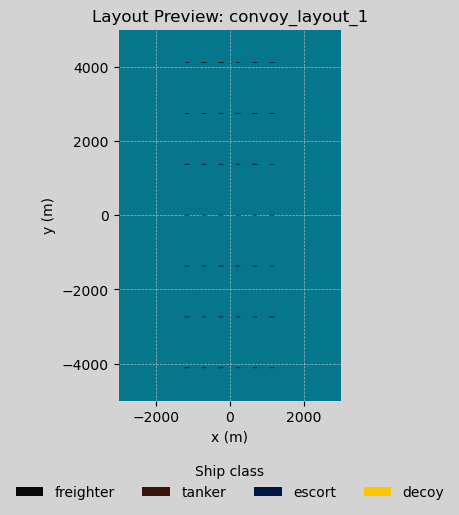

In [3]:
ships_layout_only = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
fig, ax = plt.subplots(figsize=(10, 7), facecolor='lightgrey')
plot_convoy_planview(
    ships_layout_only,
    ax=ax,
    title=f'Layout Preview: {CONVOY_PROFILE}',
    color_by='class',
    show_footprint=False,
    ship_marker='ship',
    rotate_by_heading=True,
    use_hull_dimensions=True,
    axes_facecolor='#06768d',)

ax.set_xlim(*LAYOUT_XLIM)
ax.set_ylim(*LAYOUT_YLIM)

#Drop legend down more so it does not overlap x-axis.
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((0.5, -0.3))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_aspect('equal', adjustable='box')
fig.subplots_adjust(bottom=0.35)
plt.show()


## Profile Geometry Audit (Fast pre-check)

Runs a geometry plausibility audit before rendering. This is fast and helps you fix implausible misses before expensive visual runs.


In [4]:
ships_for_audit = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
profiles = PROFILE_LIBRARY.profiles
if SELECT_PROFILE_IDS is not None:
    selected = set(SELECT_PROFILE_IDS)
    profiles = [p for p in profiles if p.profile_id in selected]
if PROFILE_LIMIT is not None:
    profiles = profiles[: int(PROFILE_LIMIT)]

audit_rows = audit_attack_profiles(profiles, ships_for_audit)
audit_by_id = {row['profile_id']: row for row in audit_rows}

AUDIT_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
with AUDIT_CSV_PATH.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            'profile_id', 'name', 'mode', 'u_pos_x', 'u_pos_y',
            'range_to_centroid_m', 'intent_bearing_rad', 'active_bearing_rad',
            'bearing_error_deg', 'spread_deg', 'flag_count', 'flags',
            'severity', 'suggested_label',
        ],
    )
    writer.writeheader()
    for row in audit_rows:
        out = dict(row)
        out['flags'] = ';'.join(row.get('flags', []))
        writer.writerow(out)

AUDIT_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
AUDIT_JSON_PATH.write_text(json.dumps(audit_rows, indent=2), encoding='utf-8')

n_implausible = sum(1 for row in audit_rows if row['suggested_label'] == 'implausible_geometry')
n_near_miss = sum(1 for row in audit_rows if row['suggested_label'] == 'credible_near_miss')
n_hit_threat = sum(1 for row in audit_rows if row['suggested_label'] == 'credible_hit_threat')

print('Audit summary:', {
    'profiles': len(audit_rows),
    'credible_hit_threat': n_hit_threat,
    'credible_near_miss': n_near_miss,
    'implausible_geometry': n_implausible,
})
print('Top 5 severity rows:')
for row in audit_rows[:5]:
    print(
        row['profile_id'],
        f"severity={row['severity']:.1f}",
        f"error={row['bearing_error_deg']:.1f}deg",
        f"flags={row['flags']}",
    )

if EXCLUDE_IMPLAUSIBLE_FROM_RENDER:
    bad = {row['profile_id'] for row in audit_rows if row['suggested_label'] == 'implausible_geometry'}
    profiles = [p for p in profiles if p.profile_id not in bad]
    print(f'Excluded {len(bad)} implausible profiles from render pass.')

print('Audit CSV written to:', AUDIT_CSV_PATH)
print('Audit JSON written to:', AUDIT_JSON_PATH)


Audit summary: {'profiles': 60, 'credible_hit_threat': 55, 'credible_near_miss': 5, 'implausible_geometry': 0}
Top 5 severity rows:
P26 severity=10.8 error=9.0deg flags=[]
P27 severity=10.8 error=9.0deg flags=[]
P28 severity=10.8 error=9.0deg flags=[]
P29 severity=10.8 error=9.0deg flags=[]
P30 severity=10.8 error=9.0deg flags=[]
Audit CSV written to: results/notebook-results/attack_profile_tests/attack_profile_geometry_audit.csv
Audit JSON written to: results/notebook-results/attack_profile_tests/attack_profile_geometry_audit.json


In [5]:
# --- Test Cell ---
REPO = str(PROJECT_ROOT)
CONVOY = "convoy_layout_1"
MODE = "verify"  # "fast" or "verify"
WORKERS = 7
SELECT = ""  # "P15,P16,P19,P21" or "" for all

#Make torpedo trails obvious for manual verification (Hard Code In to be sure)
TRAIL_LENGTH_S = 600
TRAIL_LINEWIDTH = 0.2
TRAIL_ALPHA = 0.25

cmd = (
    f'PYTHONPATH="{REPO}" python -m experiments.render_attack_profile_previews '
    f'--convoy-profile {CONVOY} --run-mode {MODE} --workers {WORKERS} '
    f'--trail-length-s {TRAIL_LENGTH_S} --trail-linewidth {TRAIL_LINEWIDTH} --trail-alpha {TRAIL_ALPHA}'
)

if SELECT.strip():
    cmd += f' --select-profile-ids {SELECT}'

print(cmd)
subprocess.run(cmd, shell=True, check=True, cwd=PROJECT_ROOT)


PYTHONPATH="/Users/matthewplambeck/Desktop/Convoy Layout Project" python -m experiments.render_attack_profile_previews --convoy-profile convoy_layout_1 --run-mode verify --workers 7 --trail-length-s 600 --trail-linewidth 0.2 --trail-alpha 0.25
Rendering 60 profiles with workers=7 ...
Completed P03 [credible_hit_threat, err=0.1deg, hits=1, ships_hit=1]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P04 [credible_hit_threat, err=0.2deg, hits=3, ships_hit=2]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P06 [credible_hit_threat, err=0.2deg, hits=3, ships_hit=2]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P07 [credible_hit_threat, err=0.3deg, hits=3, ships_hit=1]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P05 [credible_hit_threat, err=0.1deg, hits=3, ships_hit=2]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P02 [credible_hit_threat, err=0.2deg, hits=3, ships_hit=2]: frame_0001.png, frame_1500.png, frame_3000.png
Completed P01

In [6]:
# Run U-boat miss flag audit.
repo = str(PROJECT_ROOT)
cmd = 'PYTHONPATH="{}" python -m experiments.audit_attack_profiles --convoy-profile convoy_layout_1'.format(repo)
print(cmd)
subprocess.run(cmd, shell=True, check=True, cwd=PROJECT_ROOT)


Wrote CSV: results/notebook-results/attack_profile_tests/attack_profile_geometry_audit.csv
Wrote JSON: results/notebook-results/attack_profile_tests/attack_profile_geometry_audit.json
Summary: {'profiles': 60, 'credible_hit_threat': 55, 'credible_near_miss': 5, 'implausible_geometry': 0}
Top 5 highest-severity profiles:
  P26: severity=10.8, error=9.0deg, flags=[]
  P27: severity=10.8, error=9.0deg, flags=[]
  P28: severity=10.8, error=9.0deg, flags=[]
  P29: severity=10.8, error=9.0deg, flags=[]
  P30: severity=10.8, error=9.0deg, flags=[]


## All P01-P60 U-boat Spawn Locations



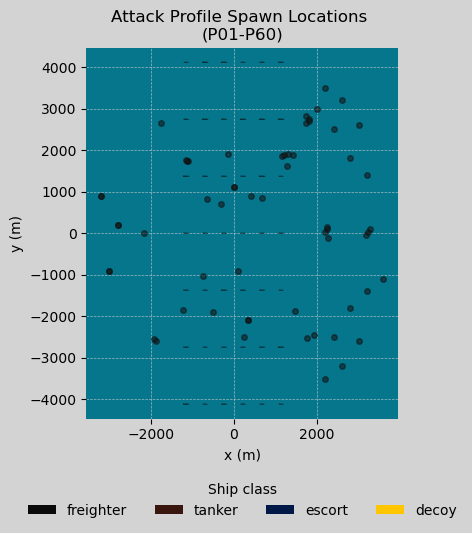

In [9]:
ships_spawn_plot = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
curated_profiles = [p for p in PROFILE_LIBRARY.profiles if str(p.profile_id).startswith("P")]
spawn_points = np.array([np.asarray(p.u_pos, dtype=float) for p in curated_profiles], dtype=float)

fig, ax = plt.subplots(figsize=(10, 7), facecolor="lightgrey")
plot_convoy_planview(
    ships_spawn_plot,
    ax=ax,
    title=f"Attack Profile Spawn Locations \n(P01-P60)",
    color_by="class",
    show_footprint=False,
    ship_marker="ship",
    rotate_by_heading=True,
    use_hull_dimensions=True,
    axes_facecolor="#06768d",)

if len(spawn_points):
    ax.scatter(
        spawn_points[:, 0],
        spawn_points[:, 1],
        c="#111111",
        s=16,
        alpha=0.55,
        zorder=3,
        label="U-boat spawn",)

combined = np.vstack([np.array([ship.position for ship in ships_spawn_plot], dtype=float), spawn_points]) if len(spawn_points) else np.array([ship.position for ship in ships_spawn_plot], dtype=float)
pad_x = 350.0
pad_y = 350.0
ax.set_xlim(float(np.min(combined[:, 0]) - pad_x), float(np.max(combined[:, 0]) + pad_x))
ax.set_ylim(float(np.min(combined[:, 1]) - pad_y), float(np.max(combined[:, 1]) + pad_y))

leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((0.5, -0.3))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(bottom=0.35)
plt.show()


# Note
- Fix overlapping U-boat positions